In [1]:
# load preprocessed AnnData object

import scanpy as sc
import numpy as np
import pandas as pd
from pathlib import Path

sc.settings.verbosity = 3

ROOT = Path("..").resolve()
DATA_DIR = ROOT / "data" / "raw"
FIG_DIR = ROOT / "figures"

adata = sc.read_h5ad(DATA_DIR / "preprocessed_data.h5ad")
print(adata)

/Users/varsha/miniforge3/envs/scrnaseq-biomarker/lib/python3.11/site-packages/scanpy/_utils/__init__.py:27: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
/Users/varsha/miniforge3/envs/scrnaseq-biomarker/lib/python3.11/site-packages/anndata/__init__.py:70: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  return module_get_attr_redirect(attr_name, deprecated_mapping=_DEPRECATED)
/Users/varsha/miniforge3/envs/scrnaseq-biomarker/lib/python3.11/site-packages/anndata/__init__.py:70: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  return module_get_attr_redirect(attr_name, deprecated_mapping=_DEPRECATED)
/Users/varsha/miniforge3/envs/scrnaseq-biomarker/lib/python3.11/site-packages/anndata/__init__.py:70: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata

AnnData object with n_obs × n_vars = 28557 × 13727
    obs: 'sample', 'donor', 'condition', 'cell_type', 'multiplets', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts'
    var: 'gene_symbol', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'hvg', 'log1p'
    layers: 'counts'


... as `zero_center=True`, sparse input is densified and may lead to large memory consumption
computing PCA
    with n_comps=50


/Users/varsha/miniforge3/envs/scrnaseq-biomarker/lib/python3.11/site-packages/scanpy/preprocessing/_pca.py:377: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  warn(msg, FutureWarning)
/Users/varsha/miniforge3/envs/scrnaseq-biomarker/lib/python3.11/site-packages/scanpy/preprocessing/_pca.py:209: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  Version(ad.__version__) < Version("0.9")


    finished (0:00:06)


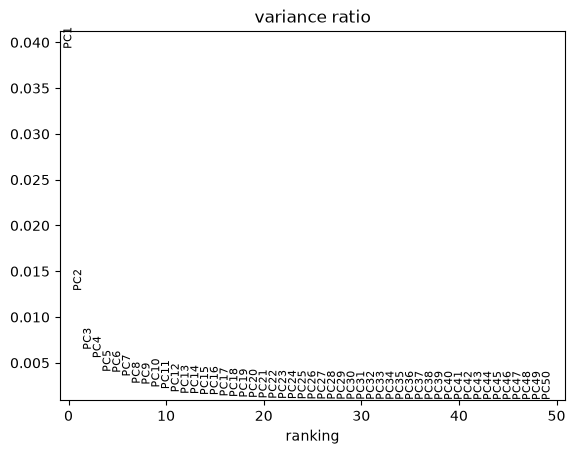

In [2]:
sc.pp.scale(adata, max_value=10)
sc.tl.pca(adata, svd_solver='arpack', use_highly_variable=True)
sc.pl.pca_variance_ratio(adata, n_pcs=50)

In [3]:
# neighbor graph construction
sc.pp.neighbors(adata, n_neighbors=15, n_pcs=20)

computing neighbors


/Users/varsha/miniforge3/envs/scrnaseq-biomarker/lib/python3.11/site-packages/scanpy/neighbors/__init__.py:423: FutureWarning: The method obsm_keys is deprecated and will be removed in the future. Use obsm instead of obsm_keys. (e.g. `k in adata.obsm` or `adata.obsm.keys() | {'u'}`)
  if "X_diffmap" in adata.obsm_keys():


    using 'X_pca' with n_pcs = 20
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:12)


In [4]:
# clustering using the Leiden algorithm
sc.tl.leiden(adata, resolution=0.5)
print(adata.obs['leiden'].value_counts())

running Leiden clustering


/var/folders/nr/2djqm8nd3bzbs_nt753qc5qc0000gn/T/ipykernel_57958/4242069530.py:2: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata, resolution=0.5)


    finished: found 16 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:00:13)
leiden
0     5712
1     5127
2     3734
3     3344
4     2325
5     2164
6     1389
7     1327
8      890
9      621
10     600
11     529
12     342
13     220
14     121
15     112
Name: count, dtype: int64


computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:08)


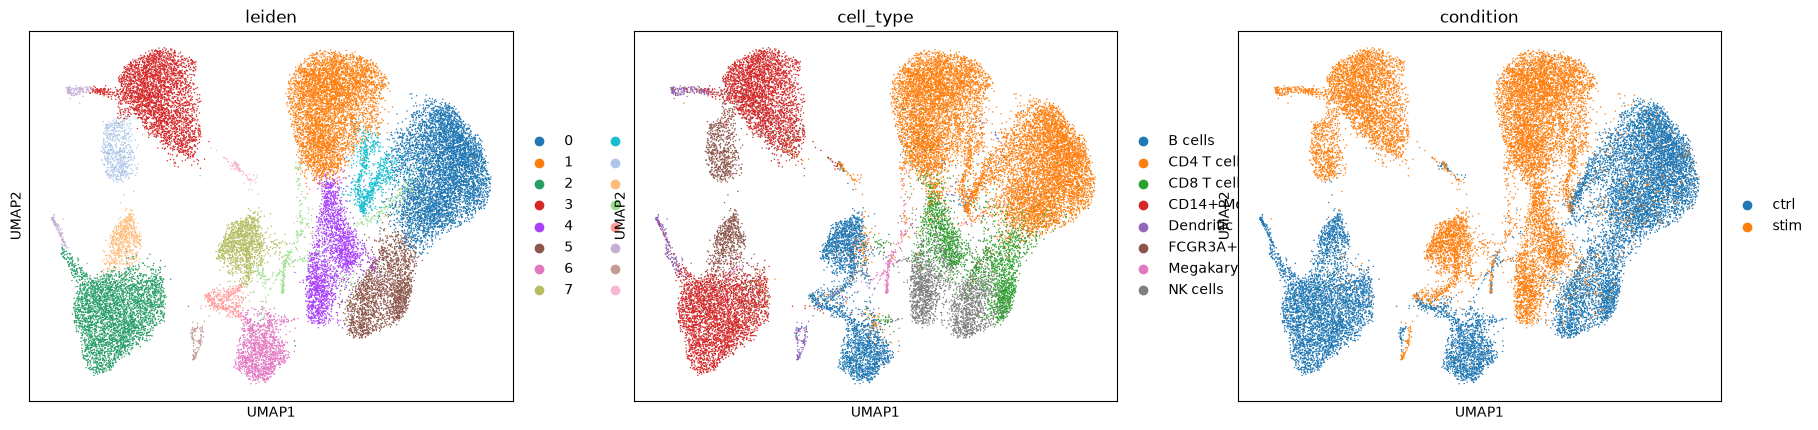

In [5]:
# visualise with UMAP
sc.tl.umap(adata)
sc.pl.umap(adata, color=['leiden', 'cell_type', 'condition'])

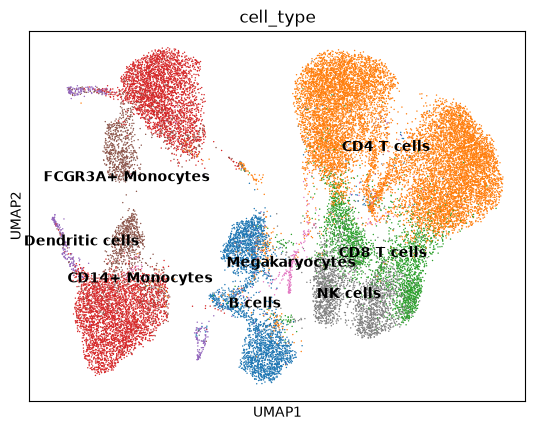

cell_type,B cells,CD4 T cells,CD8 T cells,CD14+ Monocytes,Dendritic cells,FCGR3A+ Monocytes,Megakaryocytes,NK cells
leiden,,,,,,,,
0,12,5438,245,1,3,1,6,6
1,18,5005,63,5,5,17,6,8
2,1,19,1,3291,80,305,27,10
3,0,17,0,2957,45,304,8,13
4,0,158,1028,0,0,1,0,1138
5,0,43,1103,0,0,0,0,1018
6,1278,58,32,0,4,0,2,15
7,1147,85,30,3,22,22,0,18
8,19,788,42,5,3,5,17,11


In [6]:
sc.pl.umap(adata, color='cell_type', legend_loc='on data')
pd.crosstab(adata.obs['leiden'], adata.obs['cell_type'])

In [7]:
# save the object with clustering results
adata.write_h5ad(DATA_DIR / "clustered_data.h5ad")
print("Saved!")

Saved!
